# Retail Margin & Discount Analysis Pipeline
Refined end-to-end notebook for a GitHub portfolio project aligned to data analyst and BI roles.

## 1. Imports and paths

In [1]:

from pathlib import Path
import json
import sqlite3

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 100)

project_dir = Path.cwd().resolve().parent
data_path = project_dir / "data" / "SampleSuperstore.csv"
output_dir = project_dir / "outputs"
output_dir.mkdir(exist_ok=True)


## 2. Load the dataset

In [2]:

orders = pd.read_csv(data_path)
print("Rows, columns:", orders.shape)
orders.head()


Rows, columns: (9994, 13)


,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


## 3. Standardise columns and clean key fields

In [3]:

orders.columns = (
    orders.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

numeric_cols = ["sales", "quantity", "discount", "profit", "postal_code"]
for col in numeric_cols:
    orders[col] = pd.to_numeric(orders[col], errors="coerce")

orders = orders.dropna(subset=["sales", "profit", "discount", "quantity"])
orders = orders[orders["sales"] >= 0].copy()

orders["segment"] = orders["segment"].astype(str).str.strip()
orders["state"] = orders["state"].astype(str).str.strip()
orders["category"] = orders["category"].astype(str).str.strip()
orders["sub_category"] = orders["sub_category"].astype(str).str.strip()

orders.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ship_mode     9994 non-null   object 
 1   segment       9994 non-null   object 
 2   country       9994 non-null   object 
 3   city          9994 non-null   object 
 4   state         9994 non-null   object 
 5   postal_code   9994 non-null   int64  
 6   region        9994 non-null   object 
 7   category      9994 non-null   object 
 8   sub_category  9994 non-null   object 
 9   sales         9994 non-null   float64
 10  quantity      9994 non-null   int64  
 11  discount      9994 non-null   float64
 12  profit        9994 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1015.1+ KB


## 4. Profile the data

In [4]:

profile = pd.DataFrame({
    "column": orders.columns,
    "dtype": orders.dtypes.astype(str).values,
    "missing_values": orders.isna().sum().values,
    "missing_pct": (orders.isna().mean().values * 100).round(2),
    "unique_values": [orders[c].nunique() for c in orders.columns]
})
profile.to_csv(output_dir / "data_profile.csv", index=False)
profile


,column,dtype,missing_values,missing_pct,unique_values
0,ship_mode,object,0,0.0,4
1,segment,object,0,0.0,3
2,country,object,0,0.0,1
3,city,object,0,0.0,531
4,state,object,0,0.0,49
5,postal_code,int64,0,0.0,631
6,region,object,0,0.0,4
7,category,object,0,0.0,3
8,sub_category,object,0,0.0,17
9,sales,float64,0,0.0,5825


## 5. Feature engineering

In [5]:

orders["profit_margin_pct"] = np.where(orders["sales"] > 0, (orders["profit"] / orders["sales"]) * 100, np.nan)
orders["sales_per_unit"] = np.where(orders["quantity"] > 0, orders["sales"] / orders["quantity"], np.nan)
orders["profit_per_unit"] = np.where(orders["quantity"] > 0, orders["profit"] / orders["quantity"], np.nan)
orders["loss_flag"] = (orders["profit"] < 0).astype(int)

orders["discount_band"] = pd.cut(
    orders["discount"],
    bins=[-0.001, 0, 0.1, 0.2, 0.3, 0.5, 1.0],
    labels=["0%", "1-10%", "11-20%", "21-30%", "31-50%", "50%+"]
)

orders[["sales", "profit", "quantity", "discount", "profit_margin_pct", "sales_per_unit", "profit_per_unit"]].describe().T


,count,mean,std,min,25%,50%,75%,max
sales,9994.0,229.858001,623.245101,0.4440,17.28000,54.4900,209.9400,22638.4800
profit,9994.0,28.656896,234.260108,-6599.9780,1.72875,8.6665,29.3640,8399.9760
quantity,9994.0,3.789574,2.225110,1.0000,2.00000,3.0000,5.0000,14.0000
discount,9994.0,0.156203,0.206452,0.0000,0.00000,0.2000,0.2000,0.8000
profit_margin_pct,9994.0,12.031393,46.675435,-275.0000,7.50000,27.0000,36.2500,50.0000
sales_per_unit,9994.0,60.919569,142.927440,0.3360,5.47000,16.2700,63.9400,3773.0800
profit_per_unit,9994.0,7.799372,56.074974,-1319.9956,0.72280,2.7670,8.7032,1679.9952


## 6. KPI snapshot

In [6]:

kpis = {
    "total_sales": float(orders["sales"].sum()),
    "total_profit": float(orders["profit"].sum()),
    "overall_profit_margin_pct": float((orders["profit"].sum() / orders["sales"].sum()) * 100),
    "loss_making_order_pct": float(orders["loss_flag"].mean() * 100),
    "avg_discount_pct": float(orders["discount"].mean() * 100),
    "unique_states": int(orders["state"].nunique()),
    "unique_sub_categories": int(orders["sub_category"].nunique()),
}
kpis


{'total_sales': 2297200.8603,
 'total_profit': 286397.0217,
 'overall_profit_margin_pct': 12.467217240315605,
 'loss_making_order_pct': 18.721232739643785,
 'avg_discount_pct': 15.62027216329798,
 'unique_states': 49,
 'unique_sub_categories': 17}

## 7. State, segment, and sub-category analysis

In [7]:

state_summary = (
    orders.groupby("state", as_index=False)
    .agg(
        orders=("state", "size"),
        sales=("sales", "sum"),
        profit=("profit", "sum"),
        avg_discount=("discount", "mean"),
        loss_rate=("loss_flag", "mean"),
    )
    .sort_values("profit")
)
state_summary["profit_margin_pct"] = np.where(state_summary["sales"] > 0, state_summary["profit"] / state_summary["sales"] * 100, np.nan)
state_summary.to_csv(output_dir / "state_summary.csv", index=False)

segment_summary = (
    orders.groupby("segment", as_index=False)
    .agg(
        sales=("sales", "sum"),
        profit=("profit", "sum"),
        avg_discount=("discount", "mean"),
        loss_rate=("loss_flag", "mean"),
    )
    .sort_values("profit", ascending=False)
)
segment_summary["profit_margin_pct"] = np.where(segment_summary["sales"] > 0, segment_summary["profit"] / segment_summary["sales"] * 100, np.nan)
segment_summary.to_csv(output_dir / "segment_summary.csv", index=False)

subcategory_summary = (
    orders.groupby(["category", "sub_category"], as_index=False)
    .agg(
        sales=("sales", "sum"),
        profit=("profit", "sum"),
        avg_discount=("discount", "mean"),
        quantity=("quantity", "sum"),
        loss_rate=("loss_flag", "mean"),
    )
    .sort_values("profit")
)
subcategory_summary["profit_margin_pct"] = np.where(subcategory_summary["sales"] > 0, subcategory_summary["profit"] / subcategory_summary["sales"] * 100, np.nan)
subcategory_summary.to_csv(output_dir / "subcategory_summary.csv", index=False)

display(state_summary.head(10))
display(segment_summary)
display(subcategory_summary.head(10))


,state,orders,sales,profit,avg_discount,loss_rate,profit_margin_pct
41,Texas,985,170188.0458,-25729.3563,0.370193,0.493401,-15.118192
33,Ohio,469,78258.1360,-16971.3766,0.324947,0.445629,-21.686405
36,Pennsylvania,587,116511.9140,-15559.9603,0.328620,0.473595,-13.354823
11,Illinois,492,80166.1010,-12607.8870,0.390041,0.518293,-15.727205
31,North Carolina,249,55603.1640,-7490.9122,0.283534,0.273092,-13.472097
4,Colorado,182,32108.1180,-6527.8579,0.316484,0.362637,-20.330864
40,Tennessee,183,30661.8730,-5341.6936,0.291257,0.355191,-17.421289
1,Arizona,224,35282.0010,-3427.9246,0.303571,0.379464,-9.715789
8,Florida,383,89473.7080,-3399.3017,0.299347,0.328982,-3.799219
35,Oregon,124,17431.1500,-1190.4705,0.288710,0.346774,-6.829558


,segment,sales,profit,avg_discount,loss_rate,profit_margin_pct
0,Consumer,1.161401e+06,134119.2092,0.158141,0.193219,11.548050
1,Corporate,7.061464e+05,91979.1340,0.158228,0.184106,13.025506
2,Home Office,4.296531e+05,60298.6785,0.147128,0.174986,14.034269


,category,sub_category,sales,profit,avg_discount,quantity,loss_rate,profit_margin_pct
3,Furniture,Tables,206965.5320,-17725.4811,0.261285,1241,0.636364,-8.564460
0,Furniture,Bookcases,114879.9963,-3472.5560,0.211140,868,0.478070,-3.022768
12,Office Supplies,Supplies,46673.5380,-1189.0995,0.076842,647,0.173684,-2.547695
8,Office Supplies,Fasteners,3024.2800,949.5182,0.082028,914,0.055300,31.396504
15,Technology,Machines,189238.6310,3384.7569,0.306087,440,0.382609,1.788618
9,Office Supplies,Labels,12486.3120,5546.2540,0.068681,1400,0.000000,44.418672
5,Office Supplies,Art,27118.7920,6527.7870,0.074874,3000,0.000000,24.071083
7,Office Supplies,Envelopes,16476.4020,6964.1767,0.080315,906,0.000000,42.267582
2,Furniture,Furnishings,91705.1640,13059.1436,0.138349,3563,0.174504,14.240358
4,Office Supplies,Appliances,107532.1610,18138.0054,0.166524,1729,0.143777,16.867517


## 8. Discount risk analysis

In [8]:

discount_summary = (
    orders.groupby("discount_band", observed=False, as_index=False)
    .agg(
        orders=("discount_band", "size"),
        sales=("sales", "sum"),
        profit=("profit", "sum"),
        avg_discount=("discount", "mean"),
        loss_rate=("loss_flag", "mean"),
    )
)
discount_summary["profit_margin_pct"] = np.where(discount_summary["sales"] > 0, discount_summary["profit"] / discount_summary["sales"] * 100, np.nan)
discount_summary.to_csv(output_dir / "discount_summary.csv", index=False)
discount_summary


,discount_band,orders,sales,profit,avg_discount,loss_rate,profit_margin_pct
0,0%,4798,1.087908e+06,320987.6032,0.000000,0.000000,29.505019
1,1-10%,94,5.436935e+04,9029.1770,0.100000,0.042553,16.607108
2,11-20%,3709,7.921529e+05,91756.2975,0.199299,0.139930,11.583155
3,21-30%,227,1.032267e+05,-10369.2774,0.300000,0.916300,-10.045155
4,31-50%,310,1.953148e+05,-48447.7273,0.416097,0.916129,-24.804950
5,50%+,856,6.422874e+04,-76559.0513,0.718925,1.000000,-119.197502


## 9. Correlation view for numeric fields

In [9]:

corr = orders[["sales", "quantity", "discount", "profit", "profit_margin_pct", "sales_per_unit", "profit_per_unit"]].corr(numeric_only=True)
corr.to_csv(output_dir / "correlation_matrix.csv")
corr


,sales,quantity,discount,profit,profit_margin_pct,sales_per_unit,profit_per_unit
sales,1.000000,0.200795,-0.028190,0.479064,0.003444,0.889376,0.447319
quantity,0.200795,1.000000,0.008623,0.066253,-0.005280,-0.003148,-0.007209
discount,-0.028190,0.008623,1.000000,-0.219487,-0.864452,-0.032803,-0.232313
profit,0.479064,0.066253,-0.219487,1.000000,0.223732,0.468312,0.912199
profit_margin_pct,0.003444,-0.005280,-0.864452,0.223732,1.000000,0.007044,0.240215
sales_per_unit,0.889376,-0.003148,-0.032803,0.468312,0.007044,1.000000,0.538217
profit_per_unit,0.447319,-0.007209,-0.232313,0.912199,0.240215,0.538217,1.000000


## 10. Visualise the most important findings

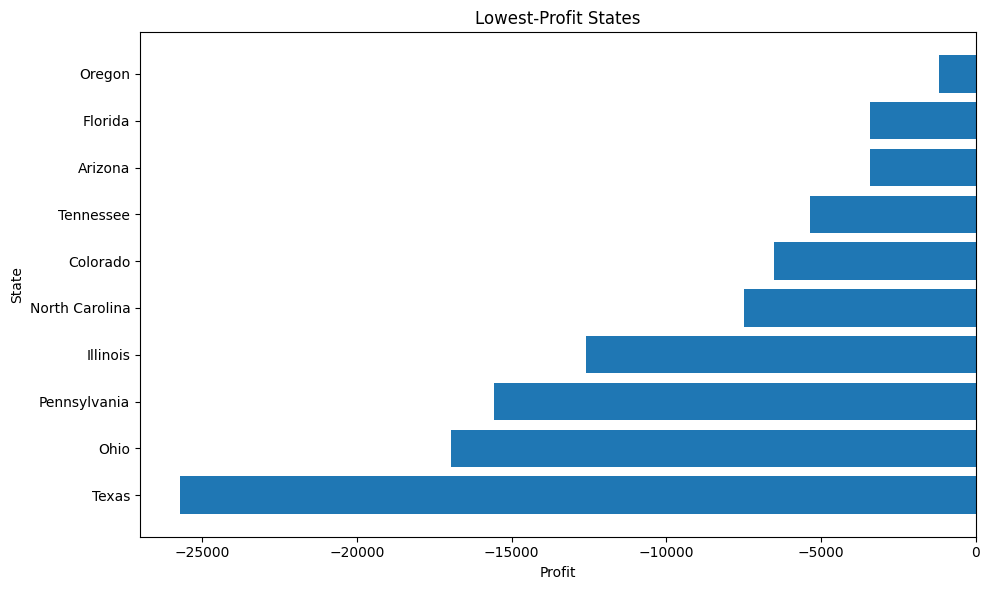

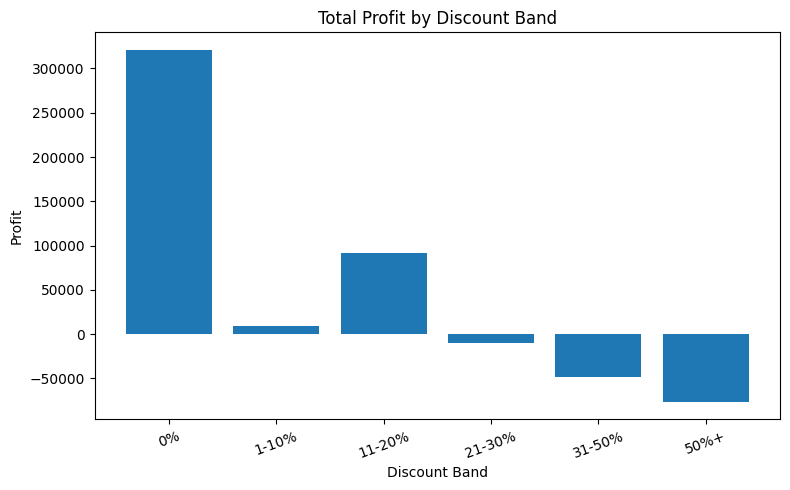

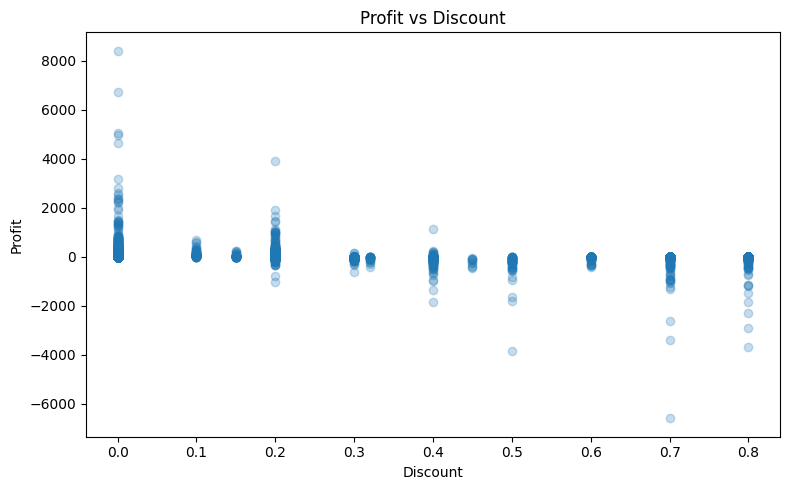

In [10]:

plt.figure(figsize=(10, 6))
state_plot = state_summary.head(10)
plt.barh(state_plot["state"], state_plot["profit"])
plt.title("Lowest-Profit States")
plt.xlabel("Profit")
plt.ylabel("State")
plt.tight_layout()
plt.savefig(output_dir / "lowest_profit_states.png", dpi=150)
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(discount_summary["discount_band"].astype(str), discount_summary["profit"])
plt.title("Total Profit by Discount Band")
plt.xlabel("Discount Band")
plt.ylabel("Profit")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(output_dir / "profit_by_discount_band.png", dpi=150)
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(orders["discount"], orders["profit"], alpha=0.25)
plt.title("Profit vs Discount")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.tight_layout()
plt.savefig(output_dir / "profit_vs_discount.png", dpi=150)
plt.show()


## 11. Export a SQL-ready table

In [11]:

db_path = output_dir / "retail_margin.db"
conn = sqlite3.connect(db_path)
orders.to_sql("orders", conn, if_exists="replace", index=False)

sql_bottom_states = pd.read_sql_query(
    '''
    SELECT state, ROUND(SUM(sales), 2) AS sales, ROUND(SUM(profit), 2) AS profit
    FROM orders
    GROUP BY state
    ORDER BY profit ASC
    LIMIT 10
    ''',
    conn
)
sql_discount_risk = pd.read_sql_query(
    '''
    SELECT discount_band,
           COUNT(*) AS order_count,
           ROUND(SUM(sales), 2) AS sales,
           ROUND(SUM(profit), 2) AS profit,
           ROUND(AVG(discount) * 100, 2) AS avg_discount_pct
    FROM orders
    GROUP BY discount_band
    ORDER BY avg_discount_pct ASC
    ''',
    conn
)
sql_subcategory = pd.read_sql_query(
    '''
    SELECT category, sub_category,
           ROUND(SUM(sales), 2) AS sales,
           ROUND(SUM(profit), 2) AS profit
    FROM orders
    GROUP BY category, sub_category
    ORDER BY profit ASC
    LIMIT 15
    ''',
    conn
)
conn.close()

sql_bottom_states.to_csv(output_dir / "sql_bottom_states.csv", index=False)
sql_discount_risk.to_csv(output_dir / "sql_discount_risk.csv", index=False)
sql_subcategory.to_csv(output_dir / "sql_subcategory.csv", index=False)

display(sql_bottom_states)
display(sql_discount_risk)


,state,sales,profit
0,Texas,170188.05,-25729.36
1,Ohio,78258.14,-16971.38
2,Pennsylvania,116511.91,-15559.96
3,Illinois,80166.10,-12607.89
4,North Carolina,55603.16,-7490.91
5,Colorado,32108.12,-6527.86
6,Tennessee,30661.87,-5341.69
7,Arizona,35282.00,-3427.92
8,Florida,89473.71,-3399.30
9,Oregon,17431.15,-1190.47


,discount_band,order_count,sales,profit,avg_discount_pct
0,0%,4798,1087908.47,320987.60,0.00
1,1-10%,94,54369.35,9029.18,10.00
2,11-20%,3709,792152.89,91756.30,19.93
3,21-30%,227,103226.65,-10369.28,30.00
4,31-50%,310,195314.76,-48447.73,41.61
5,50%+,856,64228.74,-76559.05,71.89


## 12. Final business summary

In [12]:

summary = {
    "total_sales": round(float(orders["sales"].sum()), 2),
    "total_profit": round(float(orders["profit"].sum()), 2),
    "overall_profit_margin_pct": round(float((orders["profit"].sum() / orders["sales"].sum()) * 100), 2),
    "worst_state_by_profit": state_summary.iloc[0]["state"],
    "worst_sub_category_by_profit": subcategory_summary.iloc[0]["sub_category"],
    "best_segment_by_profit": segment_summary.iloc[0]["segment"],
    "highest_risk_discount_band": discount_summary.sort_values("profit").iloc[0]["discount_band"],
}

with open(output_dir / "summary.json", "w") as f:
    json.dump(summary, f, indent=2)

summary


{'total_sales': 2297200.86,
 'total_profit': 286397.02,
 'overall_profit_margin_pct': 12.47,
 'worst_state_by_profit': 'Texas',
 'worst_sub_category_by_profit': 'Tables',
 'best_segment_by_profit': 'Consumer',
 'highest_risk_discount_band': '50%+'}

## 13. Recommendations
- Review pricing and discount guardrails for high-risk discount bands.
- Investigate low-profit states for fulfilment cost, discount policy, or product mix issues.
- Protect high-profit segments and sub-categories with margin-led decision rules.